In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
file = "/content/drive/MyDrive/avd/used_car_dataset.csv"
df = pd.read_csv(file)

df

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,Honda,City,2001,23,"98,000 km",Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000"
1,Toyota,Innova,2009,15,190000.0 km,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000"
2,Volkswagen,VentoTest,2010,14,"77,246 km",Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999"
3,Maruti Suzuki,Swift,2017,7,"83,500 km",Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000"
4,Maruti Suzuki,Baleno,2019,5,"45,000 km",Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000"
...,...,...,...,...,...,...,...,...,...,...,...
9577,Skoda,Octavia,2014,10,"105,904 km",Automatic,second,Diesel,Oct-24,"Skoda Octavia 1.9 Elegance TDI, 2014, Diesel","₹ 10,40,000"
9578,Maruti Suzuki,Alto-800,2020,4,"55,000 km",Manual,first,Hybrid/CNG,Nov-24,"Maruti Suzuki Alto 800 CNG LXI Optional, 2020,...","₹ 3,75,000"
9579,Maruti Suzuki,Ritz,2013,11,"92,000 km",Manual,first,Diesel,Nov-24,"Maruti Suzuki Ritz VDi, 2013, Diesel","₹ 4,15,000"
9580,Hyundai,Verna,2019,5,"72,000 km",Automatic,first,Petrol,Oct-24,"Hyundai Verna VTVT 1.6 AT SX Option, 2019, Petrol","₹ 8,55,000"


# **ANALISIS HARGA MOBIL BEKAS**

# **Business** **Understanding**

## **Business Objective**

* Deskripsi

Dataset ini berisi informasi terperinci mengenai inventaris mobil bekas yang mencakup berbagai merek, spesifikasi teknis, dan riwayat penggunaan. Data ini merepresentasikan kondisi pasar mobil bekas saat ini berdasarkan data unggahan hingga November 2024 yang mencakup berbagai segmen, mulai dari mobil ekonomi hingga kendaraan mewah.

* Tujuan Analisis Bisnis

Membangun sistem pendukung keputusan yang mampu memberikan rekomendasi harga jual terbaik secara otomatis guna mempercepat perputaran inventaris dan memaksimalkan profitabilitas dealer atau platform.

## **Asses Situation**

*   Ketersediaan Data: Dataset mencakup atribut fisik kendaraan dan riwayat penggunaan.

*   Kendala Data: Terdapat inkonsistensi format pada kolom numerik serta variasi pada informasi tambahan yang memerlukan pra-pemrosesan mendalam agar dapat diolah oleh mesin.

*   Risiko Proyek: Perubahan regulasi emisi atau tren pasar dapat mempengaruhi akurasi prediksi model terhadap data di masa depan jika model tidak diperbarui secara berkala.

## **Analytic Goals & Project Plan**

Apa yang ingin kita minta dari data?

* Membuat Prediksi Harga: Membuat sebuah "mesin pintar" yang bisa menebak harga jual mobil secara otomatis hanya dengan memasukkan data seperti merek, tahun, dan jarak tempuh.

* Melihat Akurasi: Memastikan tebakan mesin tersebut tidak meleset jauh dari harga asli di pasar.

* Mencari Faktor Penentu: Mencari tahu hal apa yang paling bikin harga mobil anjlok. Apakah karena usianya yang sudah tua, jarak tempuhnya yang sudah jauh, atau karena merek tertentu memang punya harga purna jual yang lebih rendah.

Langkah apa saja yang akan dilakukan?

* Merapikan Data : Membersihkan data yang berantakan, seperti menghapus simbol mata uang (₹) dan tulisan "km" agar semua menjadi angka yang bisa dihitung oleh komputer.

* Mengenal Data : Melihat tren unik, misalnya: "Apakah mobil transmisi matic selalu lebih mahal dari manual?" atau "Merek apa yang paling banyak dijual?"

* Menyiapkan Fitur: Mengubah informasi teks menjadi format yang dimengerti mesin agar bisa masuk ke dalam rumus prediksi.

* Uji Coba Model: Mencoba beberapa metode perhitungan untuk melihat mana yang paling jago dan akurat dalam menebak harga.

* Evaluasi & Laporan: Mengecek hasil akhir, memastikan model sudah siap pakai, dan merangkum hasilnya menjadi rekomendasi bisnis yang bermanfaat.

# **Data Understanding**

## **Struktur Data**

### **Informasi Lanjutan**

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9582 entries, 0 to 9581
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Brand         9582 non-null   object
 1   model         9582 non-null   object
 2   Year          9582 non-null   int64 
 3   Age           9582 non-null   int64 
 4   kmDriven      9535 non-null   object
 5   Transmission  9582 non-null   object
 6   Owner         9582 non-null   object
 7   FuelType      9582 non-null   object
 8   PostedDate    9582 non-null   object
 9   AdditionInfo  9582 non-null   object
 10  AskPrice      9582 non-null   object
dtypes: int64(2), object(9)
memory usage: 823.6+ KB


1.   Brand:  Jumlah baris: [9582] Tipe data: [object] Deskripsi: [Nama merk mobil]
2.   model:  Jumlah baris: [9582] Tipe data: [object] Deskripsi: []

1.   Year:  Jumlah baris: [9582] Tipe data: [int64] Deskripsi: [Tahun mobil diproduksi]

1.   Age:  Jumlah baris: [9582] Tipe data: [int64] Deskripsi:[Umur mobil dari masa produksi]

1.   kmDriven:  Jumlah baris: [9535] Tipe data: [object] Deskripsi: [Jarak dalam km yang sudah ditempuh oleh mobil]
2.   Transmission:  [9582] Tipe data: [object] Deskripsi: [Jenis transmisi mobil apakah matic atau manual]

2.   Owner:  Jumlah baris: [9582] Tipe data: [object] Deskripsi: [Menunjukkan sudah berapa kali mobil berpindah pemilik]



1.   FuelType:  Jumlah baris: [9582] Tipe data: [object] Deskripsi: [Jenis bahan bakar yang digunakan mobil]
2.   PostedDate: Jumlah baris: [9582] Tipe data: [object] Deskripsi: [Menunjukkan Kapan data mobil diambil]


2.   AdditionInfo:  Jumlah baris: [9582] Tipe data: [object] Deskripsi: [Informasi tambahan mengenai mobil]

1.   AskPrice:  Jumlah baris: [9582] Tipe data: [object] Deskripsi: [menunjukkan harga penawaran atau harga jual mobil]







## **Statistik Deskriptif**

In [15]:
df.describe(include='all')

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
count,9582,9582,9582.000000,9582.000000,9535,9582,9582,9582,9582,9582,9582
unique,39,400,NaN,NaN,1910,2,2,3,12,7307,1330
top,Maruti Suzuki,City,NaN,NaN,"65,000 km",Manual,first,Diesel,Nov-24,"BMW 5 Series 3.0 530D M Sport, 2016, Diesel","₹ 4,50,000"
freq,2720,330,NaN,NaN,198,4800,4800,3840,8693,26,134
mean,NaN,NaN,2016.361094,7.638906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,4.087226,4.087226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1986.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2014.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,2017.000000,7.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2019.000000,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN



---


1.   Count (Kelengkapan Data) Berdasarkan data, hampir semua kolom memiliki 9582 baris kecuali kolom kmDriven. Maka dapat disimpulkan bahwa kolom kmDriven hilang 47 data (missing values), sementara kolom yang lainnya sudah lengkap 9582 data.
2.   Unique (Nilai Unik) Berdasarkan data, terdapat 39 brand mobil yang berbeda dan 400 model berbeda.
3.   Top (Nilai yang paling sering muncul) Berdasarkan data, Mobil merk Maruti Suzuki adalah merk yang paling banyak dijual, sedangkan model mobil yang paling banyak dijual adalah model mobil Honda city.
4.   freq (frekuensi dari Top) Berdasarkan data, Maruti Suzuki muncul sebanyak 2720 kali.

---

5.   Mean (Rata-rata)


*   Kolom Year : Rata-rata tahun pembuatan mobil adalah tahun 2016.
*   Kolom Age : Rata-rata usia mobil sekitar 7,6 tahun.

6.   min & max

*   Year
    * Min = 2024
    * Max = 1986
*   Age
    * Min = 0
    * Max = 38

Kesimpulan :
* Pada kolom Year, tahun produksi mobil paling muda adalah tahun 2024, sedangkan tahun produksi mobil paling tua adalah tahun 1986
* Pada kolom Age, usia mobil paling muda adalah 0 tahun (baru di produksi), sedangkan usia mobil paling tua adalah 38 tahun
7.   Kuartil
* Year
    * 25% = 2014
    * 50% = 2017
    * 75% = 2019
* Age
    * 25% = 5
    * 50% = 7
    * 75% = 10

Kesimpulan:
* Pada kolom Year, seperempat dari mobil di dataset ini merupakan hasil produksi tahun 2014, setengah dari mobil di dataset ini merupakan hasil produksi tahun 2017, tiga per empat dari mobil di dataset ini merupakan hasil produksi tahun 2019

* Pada kolom Age, seperempat usia dari mobil di dataset ini adalah 5 tahun, setengah usia dari mobil di dataset ini adalah 7 tahun, tiga per empat usia dari mobil di dataset ini adalah 10 tahun
---
8. Standar Deviasi (std) - Variabilitas Data
* Year
    * Mean = 2016,4
    * std = 4,1
* Age
    * Mean = 7,6
    * std = 4,1

Kesimpulan :  
* Secara rata-rata, mobil yang ditawarkan adalah mobil bekas dengan pemakaian selama 7 hingga 8 tahun. Dengan nilai std 4,1 yang berarti variasi usia mobil cukup beragam
---

## **Data Type Check**

In [16]:
df.dtypes

,0
Brand,object
model,object
Year,int64
Age,int64
kmDriven,object
Transmission,object
Owner,object
FuelType,object
PostedDate,object
AdditionInfo,object


Kita akan mengecek tipe data dari setiap kolom apakah sudah sesuai atau tidak. Agar insight serta visualisasi yang akan kita buat menjadi akurat.

Dan dapat dilihat diatas, menurut saya type data diatas tidak ada yang tidak sesuai. Tetapi dibagian PostedDate bisa menggunakan integer ataupun object tergantung kenyamanan.

## **Inconsistent Values**

Pada tahap ini, kita perlu mengecek kekonsistenan data, contoh nya dalam penulisan. Hal ini dilakukan agar data tidak terduplikat dengan baris yang sebenarnya sama akan tetapi bisa terduplikat karena tidak konsisten.



  1. **kmDriven**

Pada kolom ini, dapat terlihat penggunaan (.) dan (,) yang tidak konsisten. Maka hal ini perlu ditangani dengan cara memilih salah satu antara menggunakan (.) atau (,)

In [17]:
print(df['kmDriven'].unique())

['98,000 km' '190000.0 km' '77,246 km' ... '243,000 km' '43,700 km'
 '83,228 km']


## **Missing Values**

In [18]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Brand,0.000000
model,0.000000
Year,0.000000
Age,0.000000
kmDriven,0.490503
Transmission,0.000000
Owner,0.000000
FuelType,0.000000
PostedDate,0.000000
AdditionInfo,0.000000


Pada tahap ini, kita akan melihat seberapa banyak data yang hilang pada seluruh kolom. Dan terlihat bahwa kolom kmDriven memiliki missing values sekitar 0,5%, yang dimana hal ini perlu ditangani atau dihapus.

## **Duplicated Values**

In [19]:
df[df.duplicated()]

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
146,Audi,A3,2015,9,"42,000 km",Automatic,second,Diesel,Nov-24,"Audi A3 2.0 35 TDI Attraction, 2015, Diesel","₹ 10,50,000"
152,Honda,City,2016,8,"93,000 km",Automatic,second,Petrol,Nov-24,Honda City 2016 Petrol Good Condition,"₹ 5,75,000"
199,Audi,A3,2015,9,"42,000 km",Automatic,second,Diesel,Nov-24,"Audi A3 2.0 35 TDI Attraction, 2015, Diesel","₹ 10,50,000"
221,Toyota,Camry,2015,9,"68,000 km",Automatic,second,Petrol,Nov-24,"Toyota Camry 2012-2014 Hybrid, 2015, Petrol","₹ 11,85,000"
230,Mercedes-Benz,GLE COUPE,2021,3,"32,000 km",Automatic,second,Petrol,Oct-24,Mercedes-Benz GLE COUPE 3.0 53 AMG 4MATIC Plus...,"₹ 1,18,00,000"
...,...,...,...,...,...,...,...,...,...,...,...
9510,BMW,X1,2020,4,"45,000 km",Automatic,first,Petrol,Nov-24,"BMW X1 2.0 sDrive20i SportX, 2020, Petrol","₹ 37,00,000"
9518,Volkswagen,VentoTest,2014,10,"72,900 km",Automatic,second,Diesel,Nov-24,Vento Diesel Automatic,"₹ 5,11,000"
9540,Maruti Suzuki,Celerio-X,2020,4,"142,000 km",Automatic,second,Hybrid/CNG,Nov-24,Maruti Suzuki Celerio X 2020 सीएनजी और अन्य 14...,"₹ 3,20,000"
9542,Maruti Suzuki,Celerio,2015,9,103000.0 km,Automatic,second,Petrol,Nov-24,"Maruti Suzuki Celerio 2014-2017 VXI AT, 2015, ...","₹ 3,60,000"


terlihat pada dataset ini ada data yang duplikat. Maka hal ini perlu ditangani dengan cara mengetikkan df = df.drop_duplicates()

## **Outliers Values**

In [20]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Year,1.450637
Age,1.450637


Pada tahap ini, kita akan melihat nilai ekstrem (outliers) pada kolom yang bertipe data kan numerik. Hal ini dilakukan agar mendapatkan insight yang akurat sehingga dapat memperkuat analisis dan model yang akan dibangun nantinya.

Akan tetapi memang tidak semua kolom perlu kita tangani, kita harus tetap melihat dan memahami tujuan dari setiap kolom yang ada di dataset.

Dan terlihat kolom

* Year dengan persentase 1,5%
* Age dengan persentase 1,5%

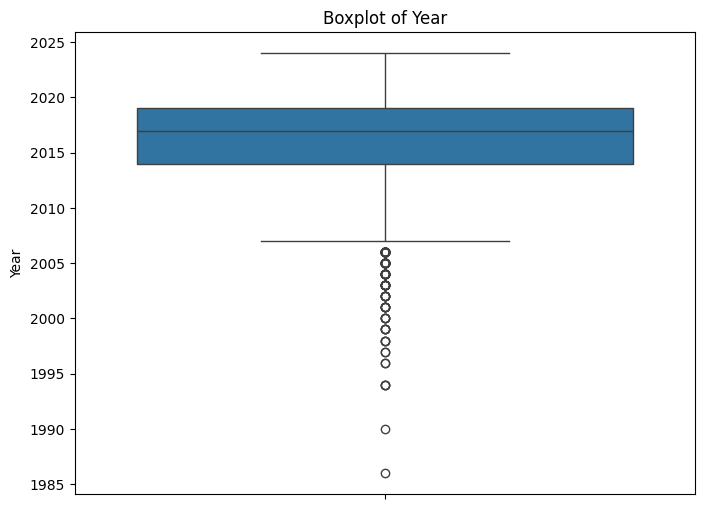

In [21]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Year'])
plt.title('Boxplot of Year')
plt.ylabel('Year')
plt.show()

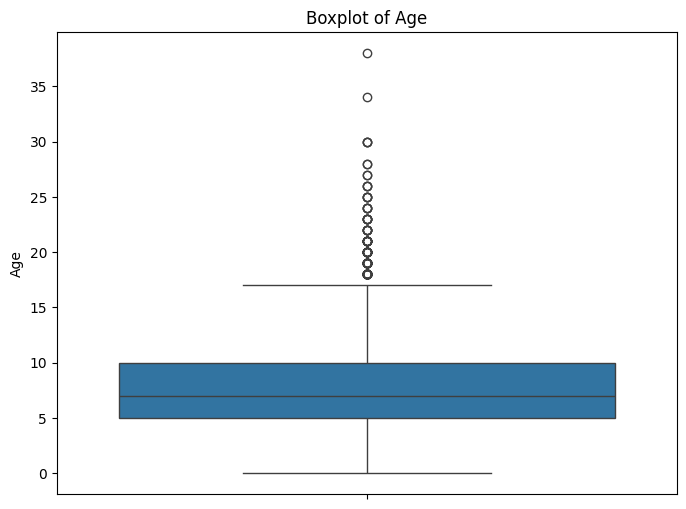

In [22]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Age'])
plt.title('Boxplot of Age')
plt.ylabel('Age')
plt.show()

Berdasarkan visualisasi diatas, bulat bulat yang ada di visualisasi adalah outliers. Jadi tidak semua outliers harus ditangani, tergantung lagi pada tujuan analisisnya.

# **Eksplorasi Data (EDA)**

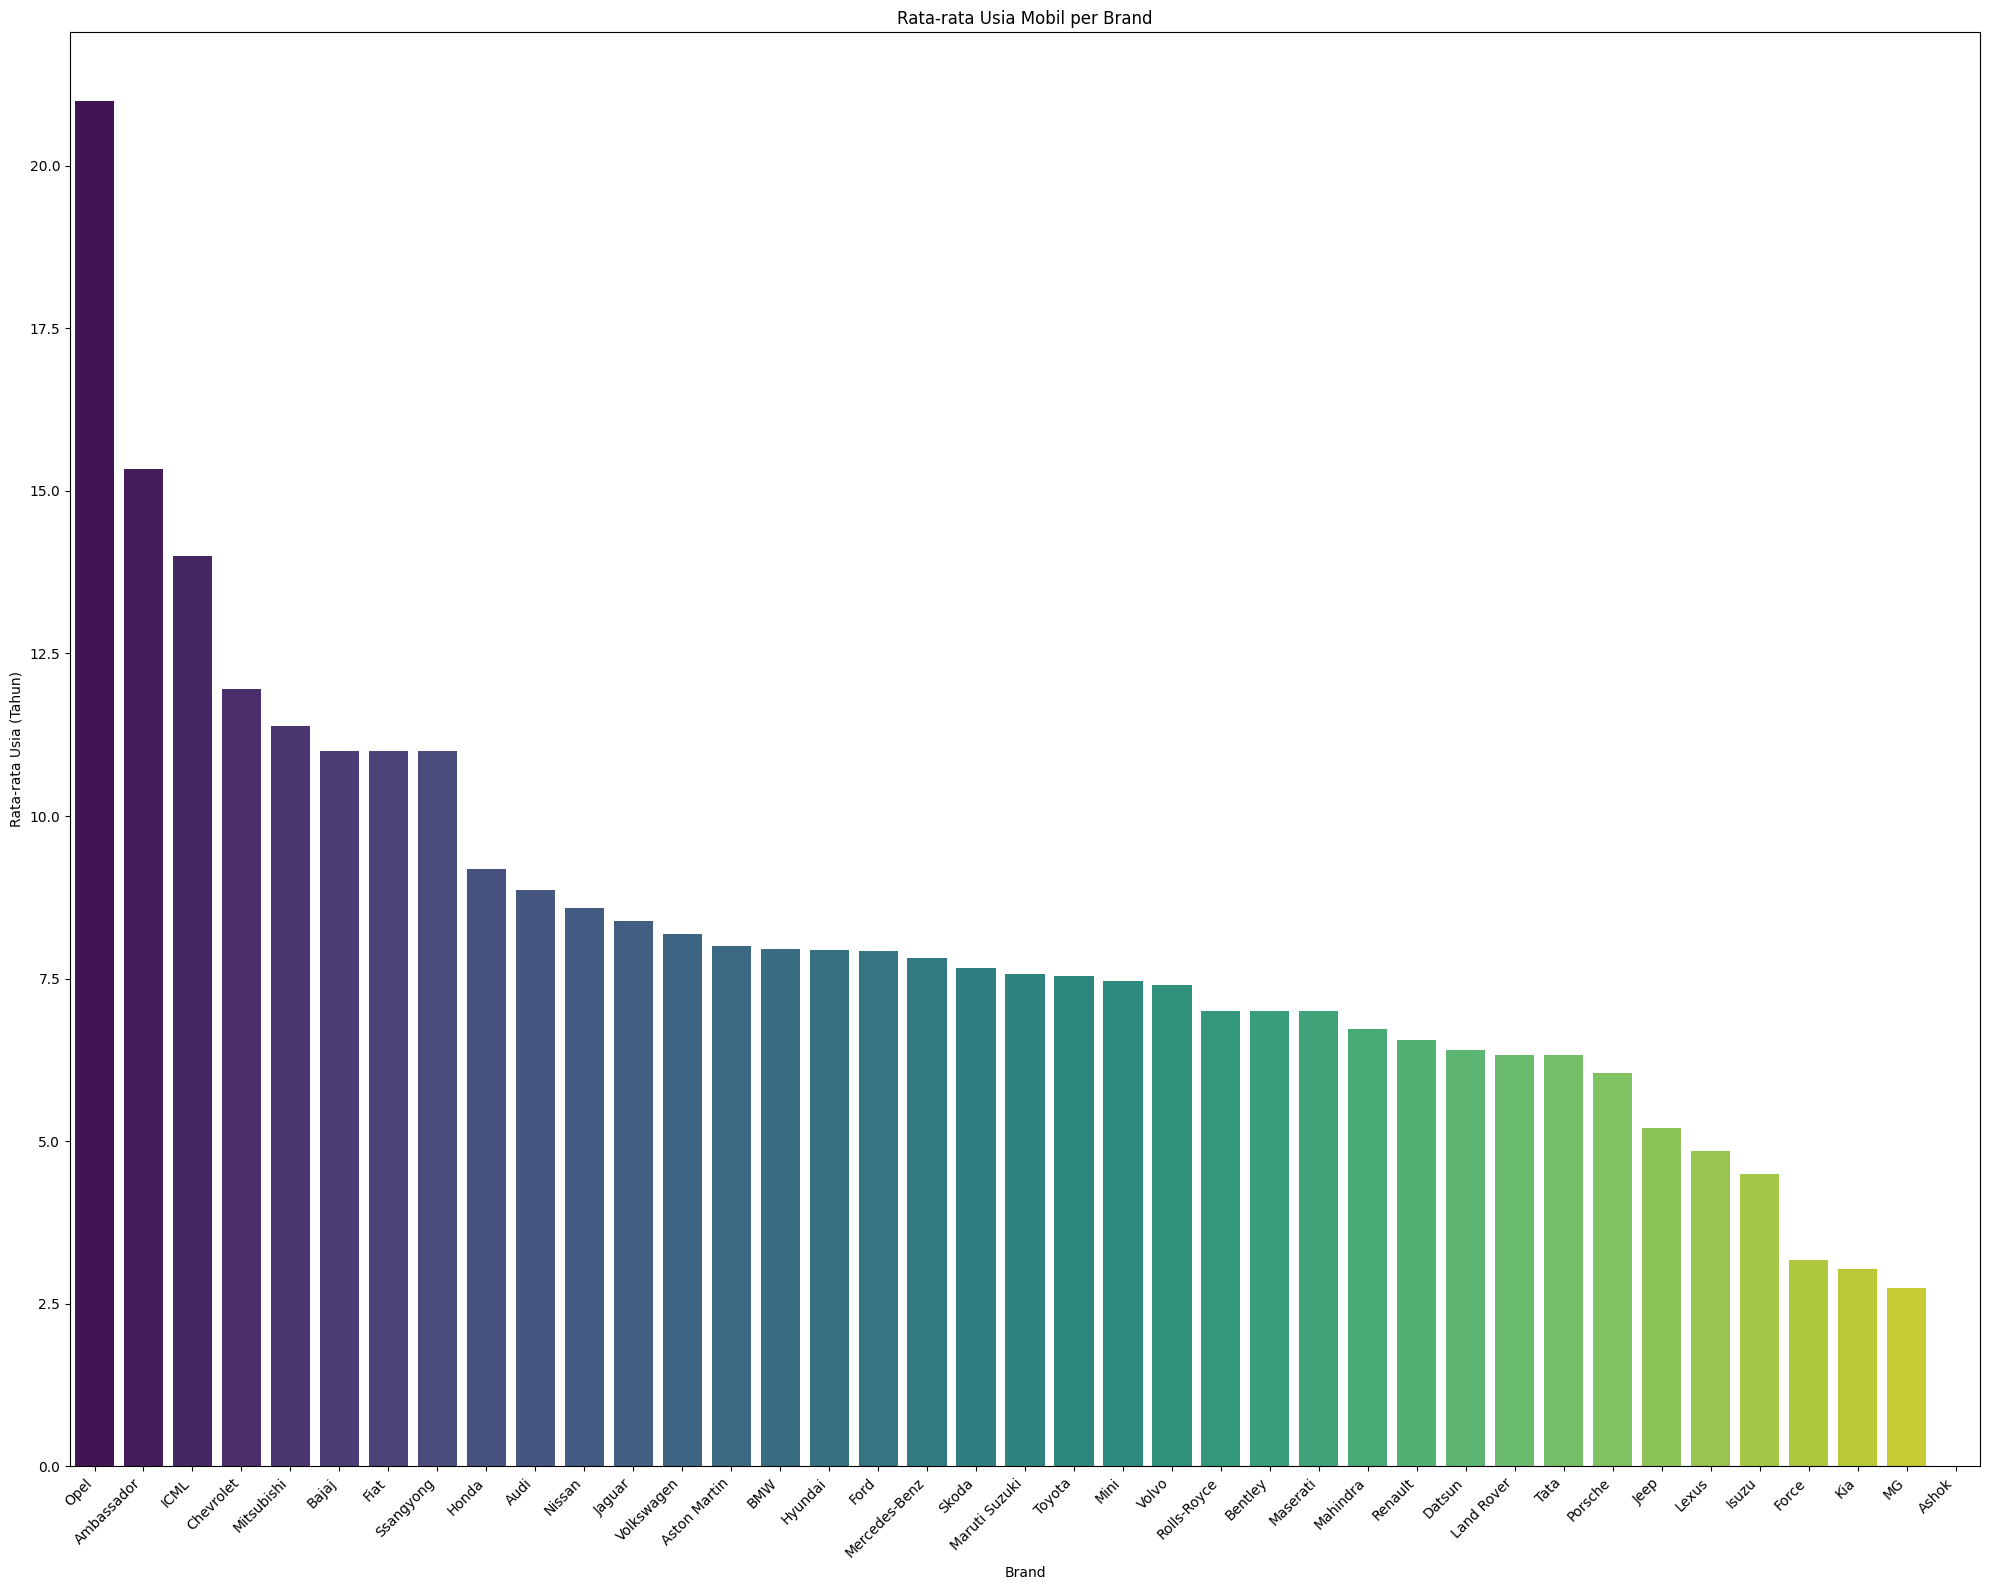

In [23]:
usia_mobil = df.groupby('Brand')['Age'].mean().sort_values(ascending=False)

plt.figure(figsize=(20,16))
sns.barplot(
    x=usia_mobil.index,
    y=usia_mobil.values,
    palette='viridis',
    hue=usia_mobil.index,
    legend=False
)

plt.title('Rata-rata Usia Mobil per Brand')
plt.xlabel('Brand')
plt.ylabel('Rata-rata Usia (Tahun)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Aktivitas: Membandingkan rata rata usia brand mobil.

Tujuan: Mengidentifikasi brand mana yang memiliki rata rata mobil yang usianya tua dan usianya muda.

Visualisasi: Bar Chart.

Kesimpulan: Berdasarkan Data, Rata-rata usia mobil yang paling tua adalah dari brand Opel. Sedangkan rata-rata usia mobil yang paling muda adalah dari brand Ashok

## **Composition/Komposisi**

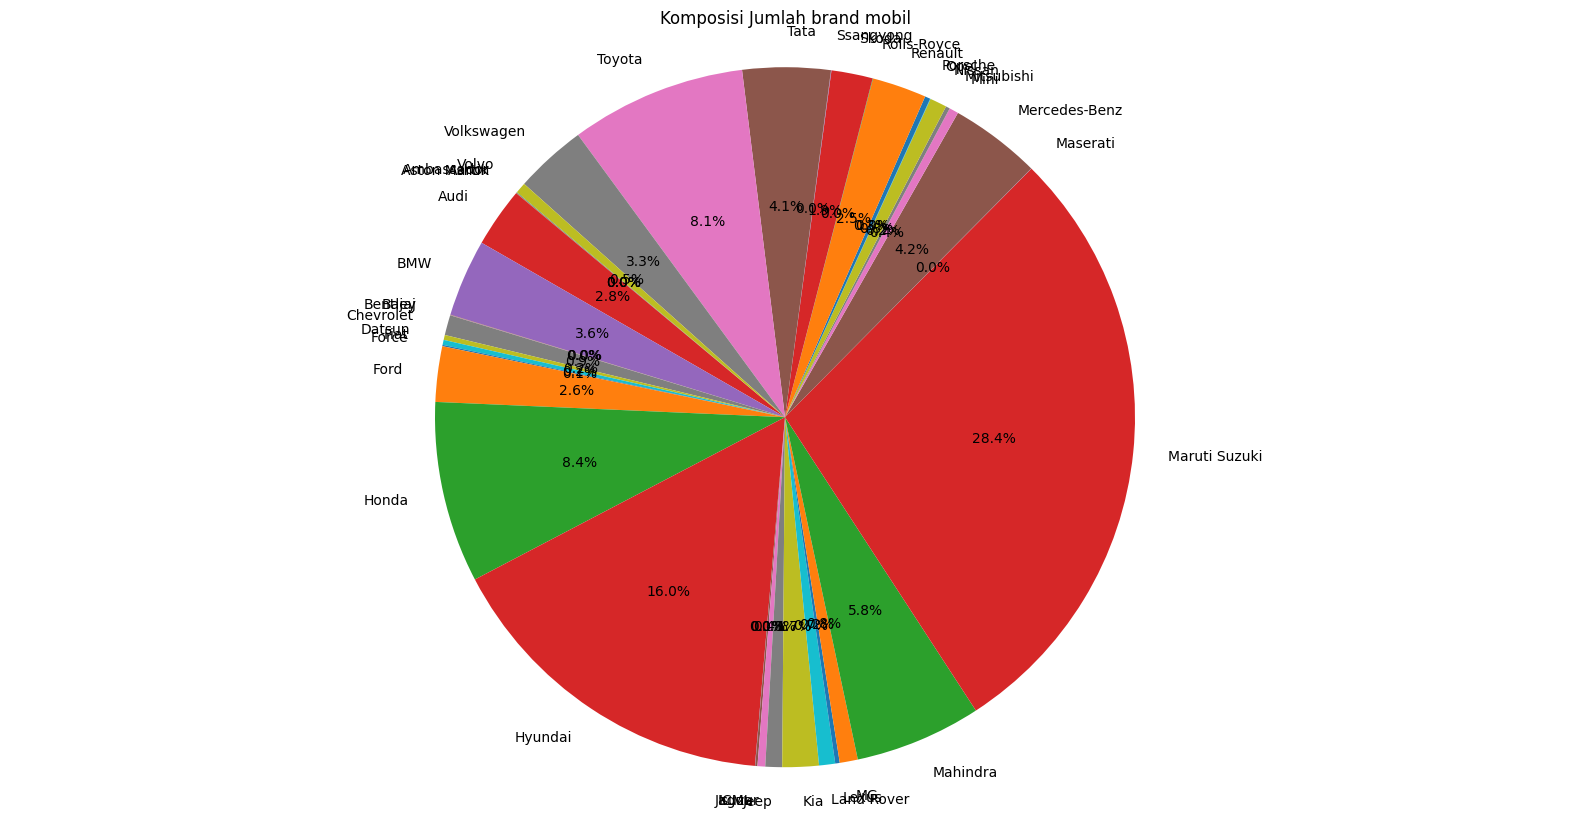

In [24]:
komposisi_brand = df['Brand'].value_counts().sort_index()

plt.figure(figsize=(20,10))
plt.pie(
    komposisi_brand,
    labels=komposisi_brand.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Komposisi Jumlah brand mobil')
plt.axis('equal')
plt.show()

Aktivitas: Melihat proporsi atau persentase jumlah mobil berdasarkan brand.

Tujuan: Mengetahui brand apa yang paling mendominasi di dalam dataset.

Visualisasi: Pie Chart.

Kesimpulan: Berdasarkan Data, Brand mobil yang paling banyak dalam dataset ini adalah brand mobil Maruti Suzuki.

## **Distribution/Distribusi**

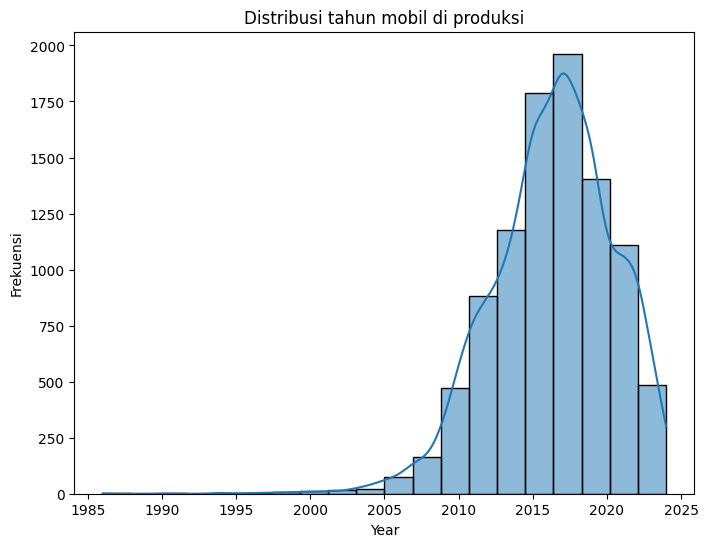

In [25]:
plt.figure(figsize=(8,6))
sns.histplot(df['Year'], bins=20, kde=True)

plt.title('Distribusi tahun mobil di produksi')
plt.xlabel('Year')
plt.ylabel('Frekuensi')
plt.show()

Aktivitas: Menganalisis distribusi produksi mobil pada kolom tahun.

Tujuan: Melihat apakah setiap tahun produksi mobil meningkat dalam dataset, serta mendeteksi adanya kecondongan (skewness) dalam data penjualan.

Visualisasi: Histogram.

Kesimpulan: Berdasarkan data, pada dataset ini distribusi mobil di produksi paling tinggi sekitar tahun 2015-2020

## **Relationship/Hubungan**

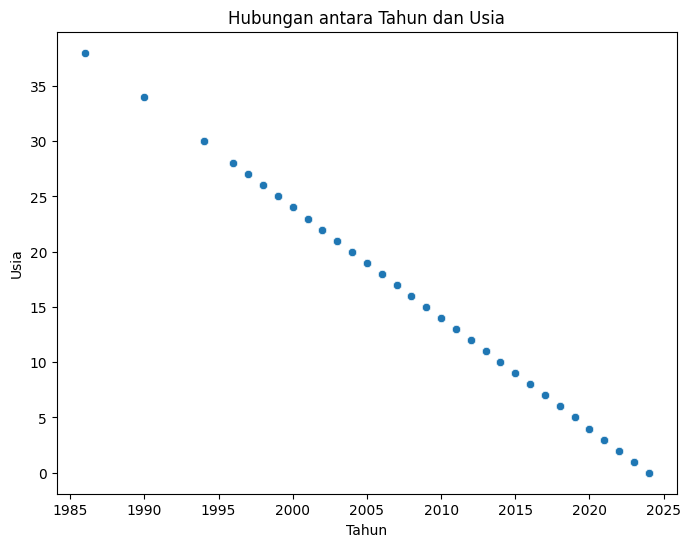

In [26]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Year', y='Age', data=df)

plt.title('Hubungan antara Tahun dan Usia')
plt.xlabel('Tahun')
plt.ylabel('Usia')
plt.show()

Aktivitas: Menganalisis korelasi antara Usia Mobil dan Tahun produksi mobil.

Tujuan: Mengetahui apakah Usia mobil mempengaruhi kapan Tahun produksi mobil dari brand tersebut.

Visualisasi: Scatterplot

Kesimpulan : Berdasarkan Data, jika tahun produksi mobil terhitung lama maka semakin tua juga usia mobil tersebut. Begitupun sebaliknya, semakin dekat tahun produksi maka semakin muda juga usia mobil tersebut.

# **Data Preparation**

## **Data Type**

## **Inconsistent Values**

Pada tahap ini, kita akan menangani ketidakkonsistenan data & tipe data, yang sudah kita temukan pada tahap verifikasi data sebelumnya. Di data sebelumnya ditemukan inconsistent values pada kolom kmDriven yang ternyata ada yang menggunakan (.) dan ada yang menggunakan (,). Saya akan menangani nya dengan kode dibawah ini.

In [27]:
df['kmDriven'] = df['kmDriven'].replace({
    '190000.0 km': '190,000 km'
})

for col in ['kmDriven']:
    print(df[col].unique())

['98,000 km' '190,000 km' '77,246 km' ... '243,000 km' '43,700 km'
 '83,228 km']


saya menggunakan kode ini karena saya ingin merubah formatnya dari (.) menjadi (,). Alasan saya mengubah dari (.) menjadi (,) dan bukan sebaliknya adalah karena mayoritas data di dataset menggunakan (,) dan bukan (.) sehingga tidak banyak yang diubah.

## **Missing Values**

Pada tahap ini kita akan menangani data yang hilang. Perlu diingat bahwa missing values sendiri jika >= 70% akan dihapus, dan <= 70% akan diimputasi.

Tentu ini bukan menjadi patokan sepenuhnya, kita harus tetap memahami kolom tersebut (tujuannya apa?) dan insight apa yang ingin kita hasilkan pada dataset ini.

In [28]:
print((df.isna().sum() / len(df)) * 100)

Brand           0.000000
model           0.000000
Year            0.000000
Age             0.000000
kmDriven        0.490503
Transmission    0.000000
Owner           0.000000
FuelType        0.000000
PostedDate      0.000000
AdditionInfo    0.000000
AskPrice        0.000000
dtype: float64


Pada kolom kmDriven terlihat memiliki persentase missing values sekitar 0,5%, ini masih dapat diimputasi.

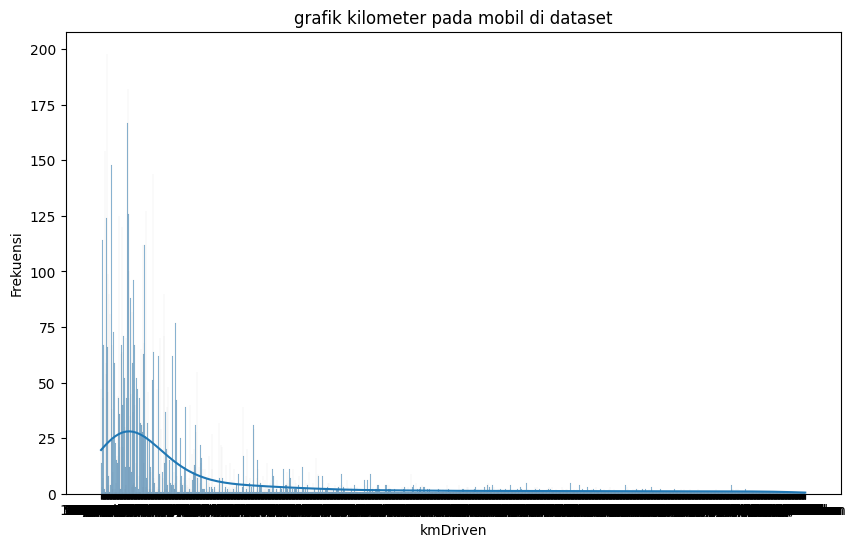

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(df['kmDriven'], bins=20, kde=True)
plt.title('grafik kilometer pada mobil di dataset')
plt.xlabel('kmDriven')
plt.ylabel('Frekuensi')
plt.show()

Karena grafik yang dihasilkan tidak jelas dan saling tindih maka dari itu saya memutuskan untuk mengubah kolom kmDriven menjadi Integer.

In [30]:
df['kmDriven'] = df['kmDriven'].str.replace(' km', '', regex=False).str.replace(',', '', regex=False)

In [31]:
df['kmDriven'] = pd.to_numeric(df['kmDriven'])

Agar dapat diubah menjadi Integer, kolom ini harus diubah ke float dulu karena ada data yang memiliki angka 190000.0 maka dari itu tidak bisa langsung ke Integer.

In [32]:
df.dtypes

,0
Brand,object
model,object
Year,int64
Age,int64
kmDriven,float64
Transmission,object
Owner,object
FuelType,object
PostedDate,object
AdditionInfo,object


Dapat dilihat kolom kmDriven sudah berubah menjadi float

In [33]:
df['kmDriven'] = df['kmDriven'].astype(float).astype('Int64')

sebelum menjadi integer harus diubah dulu ke Int64. Ini adalah tipe data khusus Pandas yang mendukung missing values, berbeda dengan integer yang error jika ada bertemu data kosong.

In [34]:
df.dtypes

,0
Brand,object
model,object
Year,int64
Age,int64
kmDriven,Int64
Transmission,object
Owner,object
FuelType,object
PostedDate,object
AdditionInfo,object


Dapat dilihat kolom kmDriven sudah berubah menjadi Int64

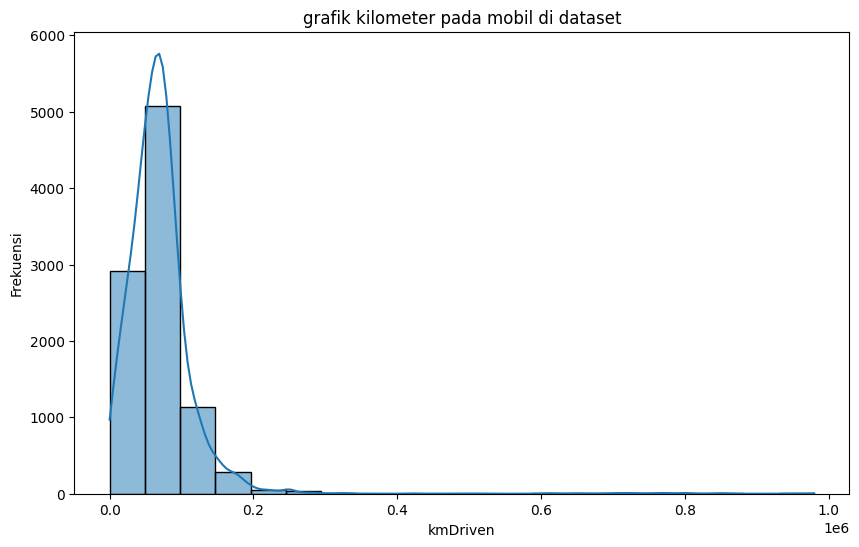

In [35]:
plt.figure(figsize=(10, 6))
sns.histplot(df['kmDriven'], bins=20, kde=True)
plt.title('grafik kilometer pada mobil di dataset')
plt.xlabel('kmDriven')
plt.ylabel('Frekuensi')
plt.show()

Pada grafik ini kita dapat melihat bahwa data ini condong ke kanan (Skewed Right) karena itu lebih baik menggunakan nilai Median, karena jika menggunakan mean maka data kosong yang akan diisi akan memiliki nilai yang terlalu tinggi.

In [36]:
df['kmDriven'] = df['kmDriven'].fillna(df.groupby('Year')['kmDriven'].transform('median'))

Agar lebih akurat, saya imputasi berdasarkan Year (Tahun keluaran mobil). Daripada menggunakan nilai median keseluruhan, lebih baik data yang kosong diisi dengan nilai median dari masing masing tahunnya.

Analogi :     
(mobil keluaran tahun 2023 rata-rata punya kilometer jauh lebih rendah dibandingkan mobil tahun 2010.)

In [37]:
df['kmDriven'] = df['kmDriven'].astype(int)

Setelah data yang kosong diisi, maka tipe datanya bisa diubah menjadi Integer.

In [38]:
df.dtypes

,0
Brand,object
model,object
Year,int64
Age,int64
kmDriven,int64
Transmission,object
Owner,object
FuelType,object
PostedDate,object
AdditionInfo,object


Dapat dilihat tipe datanya sudah berubah menjadi Integer

In [39]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio %'])

,Null Ratio %
Brand,0.0
model,0.0
Year,0.0
Age,0.0
kmDriven,0.0
Transmission,0.0
Owner,0.0
FuelType,0.0
PostedDate,0.0
AdditionInfo,0.0


Missing Values sudah ditangani menggunakan nilai Median per tahun, maksudnya adalah mobil dengan tahun muda dan datanya kosong akan diisi dengan median dari kilometer mobil tahun muda tersebut, sedangkan tahun tua juga akan diisi dengan median dari kilometer tahun tua agar datanya tetap realistis.

Misalnya:
Tahun 2022 (15000)
Tahun 2010 (120000)

## **Duplicated Values**

Terlihat pada dataset ini ada duplikasi data maka hal ini perlu ditangani.

In [40]:
df = df.drop_duplicates()

In [41]:
df[df.duplicated()]

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice


Data yang duplikat sudah berhasil ditangani.

## **Outliers Values**

Outliers adalah nilai yang jauh berbeda dari nilai lainnya dalam dataset. Nilai Outlier bisa jauh lebih rendah atau lebih tinggi. Outlier bisa terjadi karena berbagai alasan seperti faktor kesalahan maupun kejadian lain yang tidak terduga.

In [42]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Year,1.502655
Age,1.502655
kmDriven,3.818778


Ada 3 kolom yang memiliki outliers yaitu Year, Age, dan kmDriven. Hal ini tidak perlu ditangani karena nilainya masih wajar dan tujuan analisis bisnis ini adalah membantu membuat pilihan mobil berdasarkan rekomendasi harga jual terbaik.

## **Data Reduction**

Tahap Data Reduction (Pengurangan Data) bertujuan untuk menyederhanakan dataset Anda tanpa menghilangkan informasi penting. Fokusnya adalah membuang data yang "berisik" (noisy), tidak relevan, atau terlalu detail sehingga proses analisis menjadi lebih cepat dan hasil visualisasinya lebih bersih.

Kita akan menghapus kolom Age karena sudah ada kolom Year yang memiliki maksud yang sama.

In [43]:
df = df.drop('Age', axis=1)

# **Visualisasi Data**

## **Bar Chart**

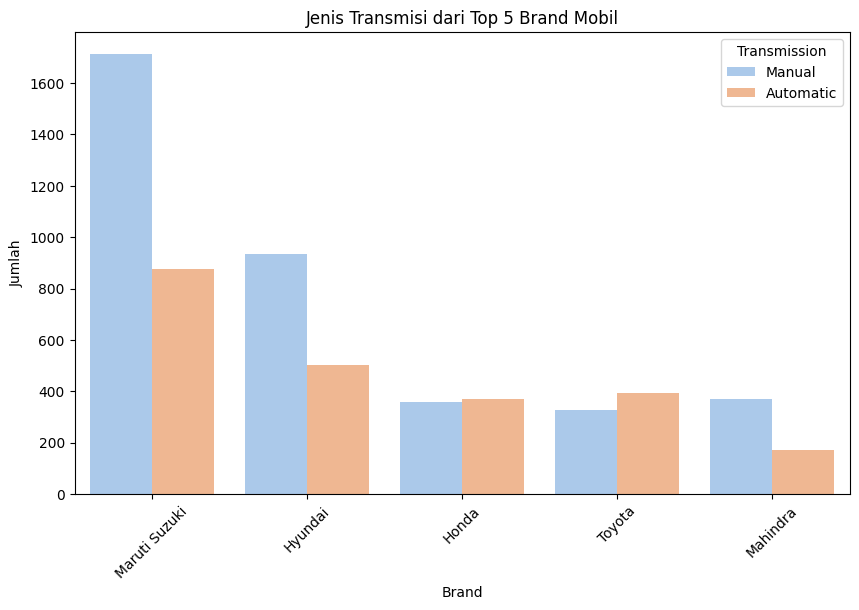

In [64]:
# Bar Chart (Seaborn)
top5negara = df['Brand'].value_counts().head(5).sort_values(ascending=False) # head() jumlah yang mau ditampilkan & Urutan
df_filtered = df[df['Brand'].isin(top5negara.index)]

plt.figure(figsize=(10, 6)) # Ukuran
sns.countplot(x='Brand', data=df_filtered, hue="Transmission", palette='pastel', order=top5negara.index) # palette (warna)
plt.title('Jenis Transmisi dari Top 5 Brand Mobil') # Judul
plt.xlabel('Brand') # Keterangan X
plt.ylabel('Jumlah') # Keterangan Y
plt.xticks(rotation=45)
plt.show()

Maruti Suzuki, Mahindra, dan Hyundai didominasi secara signifikan oleh transmisi Manual. Sebaliknya, Honda dan Toyota memiliki jumlah unit Automatic yang lebih banyak, menunjukkan segmen pembeli merek ini lebih mengutamakan kenyamanan berkendara.


---
Berdasarkan hasil diatas, penjual mobil bekas harus dapat action kedepannya dengan cara:

* Prioritaskan membeli unit mobil berdasarkan Transmisi yang paling banyak di produksi pada brand tersebut.
* Jangan menjual Toyota dan Honda dengan narasi irit saja. Karena stoknya didominasi varian Automatic, arahkan iklan kepada pekerja kantoran atau wanita yang mencari kemudahan berkendara tanpa rasa lelah.


## **Pie Chart**

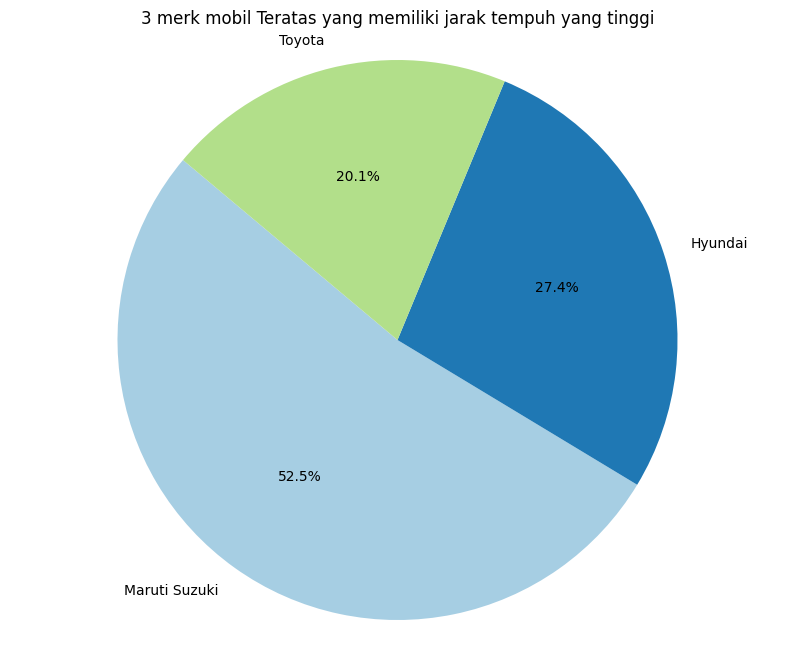

In [60]:
# Pie Chart (Matplotlib) (Berdasarkan Kolom Lain)
sales_by_category = df.groupby('Brand')['kmDriven'].sum().sort_values(ascending=False)
sales_by_category_top3 = sales_by_category.head(3)

plt.figure(figsize=(10, 8)) # Ukuran
sales_by_category_top3.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('3 merk mobil Teratas yang memiliki jarak tempuh yang tinggi') # Judul
plt.ylabel('') # Keterangan Y
plt.axis('equal')
plt.show()

**Maruti Suzuki**: Merek Maruti Suzuki memegang porsi terbesar (52,5%) dalam kategori mobil dengan jarak tempuh tinggi. Artinya unit Maruti Suzuki sering digunakan sebagai mobil harian yang intensif.

**Hyundai dan Toyota**: Sebagai merek mobil dengan penggunaan jarak tempuh yang melebihi merk lainnya. Artinya kedua merk ini juga sering digunakan sebagai mobil harian tapi tidak se intensif Maruti Suzuki.

---
Berdasarkan hasil diatas, penjual mobil bekas harus dapat action kedepannya dengan cara:

* Untuk unit Maruti Suzuki dengan jarak tempuh tinggi, fokuslah pada kemudahan perawatan dan ketersediaan suku cadang yang murah.

* Untuk unit Toyota dan Hyundai dengan jarak tempuh tinggi, tonjolkan histori servis dan daya tahan mesin untuk meyakinkan pembeli bahwa angka kilometer bukan hambatan.



## **Line Chart**

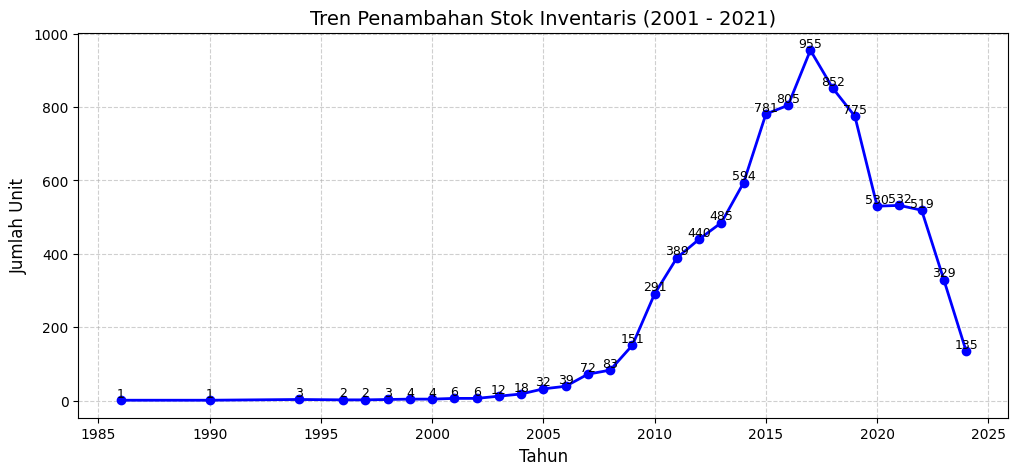

In [55]:
# 1. Menghitung jumlah mobil per tahun (Agregasi)
# Kita urutkan berdasarkan tahun (index) agar garis mengalir dengan benar
data_tren = df['Year'].value_counts().sort_index()

# 2. Membuat Line Chart
plt.figure(figsize=(12, 5))
plt.plot(data_tren.index, data_tren.values, marker='o', linestyle='-', color='blue', linewidth=2)

# Menambahkan label angka di setiap titik agar lebih informatif bagi klien
for x, y in zip(data_tren.index, data_tren.values):
    plt.text(x, y, str(y), color='black', fontsize=9, ha='center', va='bottom')

plt.title('Tren Penambahan Stok Inventaris (2001 - 2021)', fontsize=14)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Jumlah Unit', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

**Dominasi Mobil Muda**: Grafik menunjukkan lonjakan volume pada kendaraan produksi tahun 2014 ke atas. Artinya pasar saat ini didominasi dengan mobil berusia 5–10 tahun.

**Kelangkaan Mobil Tua**: Terdapat penurunan drastis atau volume yang sangat rendah untuk mobil produksi di bawah tahun 2010 pada dataset ini. Hal ini bisa berarti mobil tersebut sudah jarang di pasar jual beli.


---
Berdasarkan hasil diatas, penjual mobil bekas harus dapat action kedepannya dengan cara:


* penjual harus mulai melakukan promosi agresif atau diskon paket untuk mobil
tahun muda guna mempercepat perputaran uang, karena depresiasi harga pada mobil "muda" jauh lebih cepat dibandingkan mobil tua.


## **Histogram**

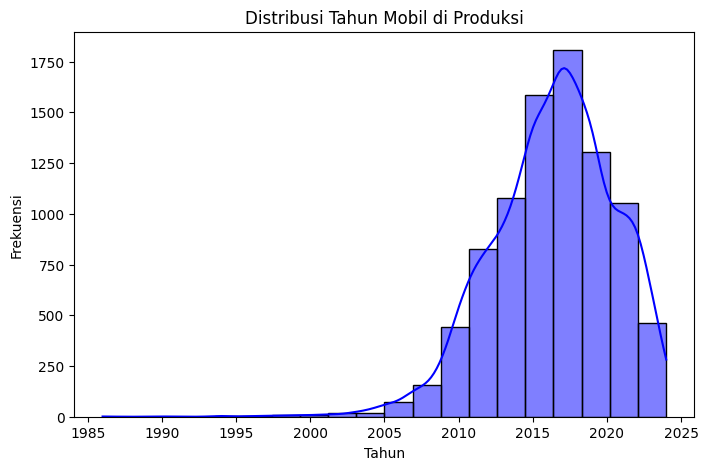

In [62]:
# Histogram (Seaborn)
plt.figure(figsize=(8, 5))
sns.histplot(df['Year'], bins=20, kde=True, color='blue')
plt.title('Distribusi Tahun Mobil di Produksi')
plt.xlabel('Tahun')
plt.ylabel('Frekuensi')
plt.show()

Grafik menunjukkan bahwa mayoritas stok kendaraan berada di rentang tahun produksi 2014 hingga 2019, dengan puncak produksi tertinggi pada tahun 2017-2018. Unit di bawah tahun 2010 memiliki jumlah yang sangat sedikit, yang berarti fokus pasar saat ini adalah mobil berusia 5-10 tahun.


---
Berdasarkan hasil diatas, penjual mobil bekas harus dapat action kedepannya dengan cara:

* Percepat Perputaran Stok 2015-2018 Karena jumlah stok pada rentang tahun ini sangat melimpah, penjual harus melakukan promosi agresif untuk menghindari penumpukan barang yang nilainya terus menyusut setiap tahun.

* Edukasi Pembeli tentang Pajak/Validasi: Karena ada unit tua (2001) yang masih dijual, pastikan kelengkapan dokumen seperti perpanjangan pajak disertakan dalam brosur untuk meningkatkan kepercayaan pembeli terhadap aspek legalitas mobil tua.

## **Boxplot**

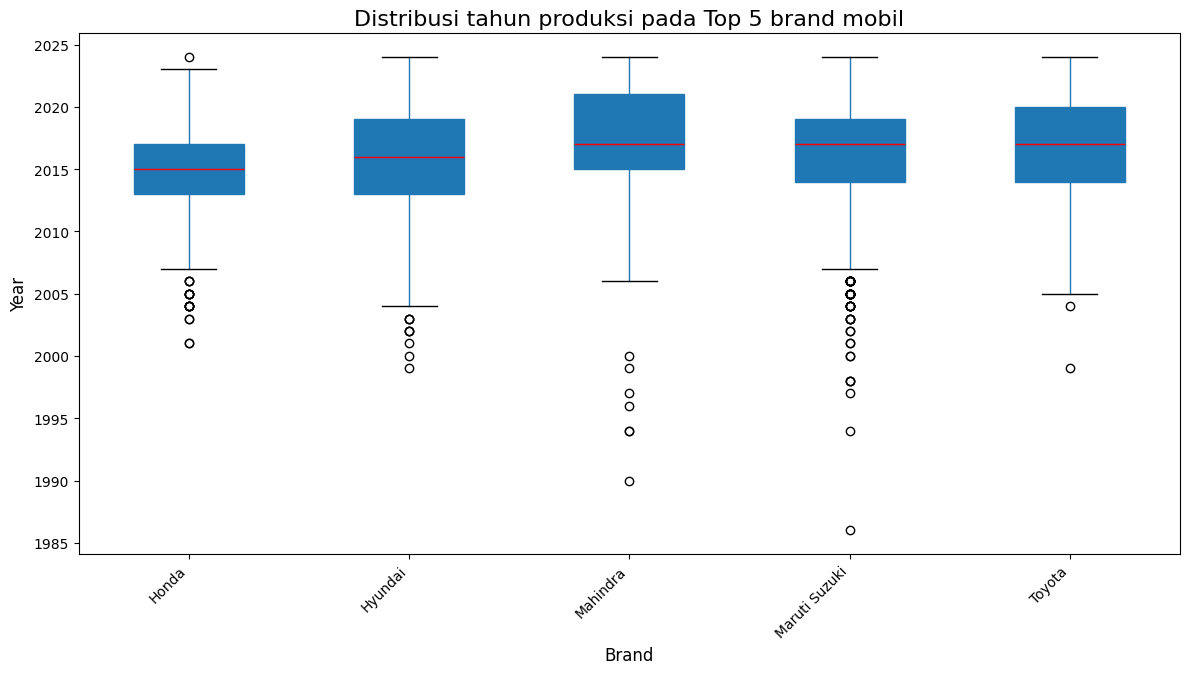

In [44]:
top5menu = df['Brand'].value_counts().head(5).index
df_top5_menu = df[df['Brand'].isin(top5menu)]

plt.figure(figsize=(12, 7)) # Ukuran figure
df_top5_menu.boxplot(column='Year', by='Brand', ax=plt.gca(), grid=False, patch_artist=True, medianprops=dict(color='red'))

plt.title('Distribusi tahun produksi pada Top 5 brand mobil', fontsize=16) # Judul
plt.xlabel('Brand', fontsize=12) # Keterangan X
plt.ylabel('Year', fontsize=12) # Keterangan Y

plt.xticks(rotation=45, ha='right')
plt.suptitle('') # Menghilangkan judul default dari boxplot.by
plt.tight_layout()

plt.show()

**Mahindra**: Berdasarkan kotak biru Mahindra. Kotaknya berada paling tinggi dibanding yang lain. Ini artinya, mayoritas mobil Mahindra yang ada di data ini adalah mobil-mobil keluaran tahun baru sekitar 2015 ke atas.

**Honda**: Kotak Honda terlihat lebih pendek. Ini menunjukkan tahun produksi mobil Honda tidak terlalu terpencar jauh rata-rata berkumpul di tahun 2013 sampai 2017. Terlihat juga ada titik diatas kotak biru Honda yang artinya ada satu atau beberapa unit mobil yang tahun produksinya lebih baru sekitar tahun 2024.

**Maruti Suzuki**: Berdasarkan titik-titik hitam di bawah kotak Maruti Suzuki. Titik-titik itu adalah mobil yang tahun produksinya sangat lama, bahkan ada yang dari tahun 1985-1990. Maruti Suzuki punya paling banyak mobil tua dibanding merk lain.

**Toyota**: Kotak Toyota berada di posisi yang cukup tinggi dan seimbang, seperti brand Mahindra, yang menandakan stok mobil mereka didominasi tahun-tahun muda.


---
Berdasarkan hasil diatas, penjual mobil bekas harus dapat action kedepannya dengan cara:


*   Perbanyak stok Honda dan Toyota tahun 2015-an. Mobil ini paling gampang dijual karena pembelinya banyak dan harganya sudah terukur
*   Pastikan modal banyak jika membeli Mahindra karena harga belinya pasti masih tinggi. Tapi untungnya, karena mobilnya masih muda, risiko rusaknya kecil.

*   Jadikan Maruti Suzuki sebagai pilihan untuk pembeli yang punya budget pas-pasan. Penjual bisa beli mobil-mobil Suzuki tahun tua ini dengan harga sangat miring, diperbaiki sedikit lalu dijual






## **Scatterplot**

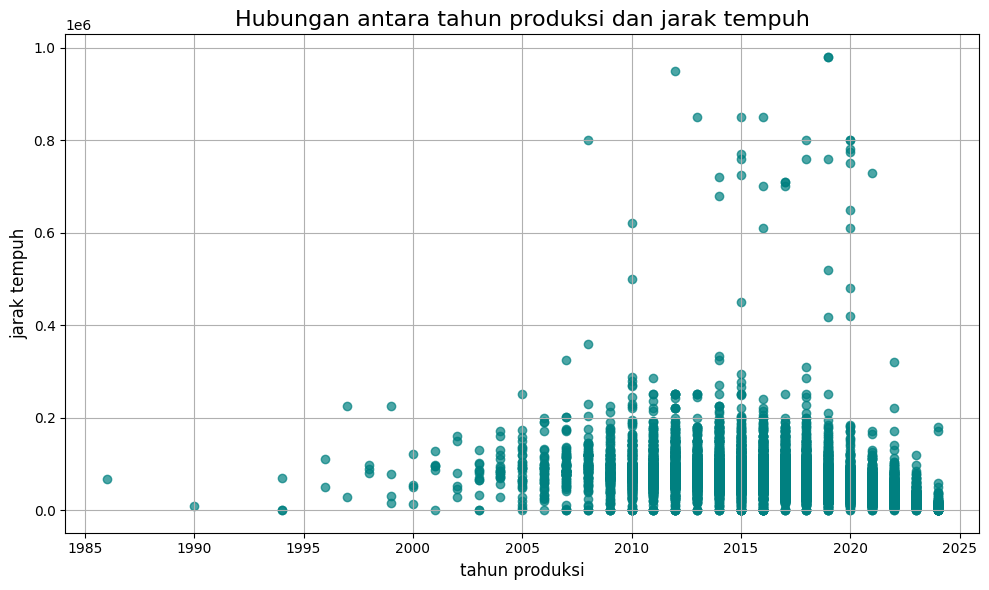

In [67]:
plt.figure(figsize=(10, 6)) # Ukuran
plt.scatter(df['Year'], df['kmDriven'], alpha=0.7, color='teal') # Color (Warna)
plt.title('Hubungan antara tahun produksi dan jarak tempuh', fontsize=16) # Judul
plt.xlabel('tahun produksi', fontsize=12) # X Keterangan
plt.ylabel('jarak tempuh', fontsize=12) # Y Keterangan
plt.grid(True)
plt.tight_layout()
plt.show()

**Pola Penggunaan Kendaraan**: Grafik ini menunjukkan sebaran seberapa jauh mobil telah dikendarai berdasarkan tahun produksinya.

**Unit Ekstrem**: Titik-titik yang melompat ke atas adalah unit-unit yang digunakan secara sangat intensif. Contohnya ada pada tahun 2012, 2015, dan 2019 di mana terdapat mobil yang jarak tempuhnya tinggi. Ini kemungkinan besar adalah mobil operasional perusahaan atau transportasi umum.

**Standar Mobil Bekas Layak Pakai**: Kepadatan warna hijau yang sangat pekat di bagian bawah untuk mobil tahun 2010-2024. Ini adalah zona normal untuk mobil pemakaian pribadi.

**Mobil Tua antik**: Mobil tua yang jarak tempuhnya justru rendah. Artinya ini adalah indikasi mobil tua yang jarang dipakai atau antik.


---
Berdasarkan hasil diatas, penjual mobil bekas harus dapat action kedepannya dengan cara:

* Filter Ketat untuk Stok 2015-2019: Karena pada tahun-tahun ini banyak terdapat unit dengan kilometer sedang ke tinggi, penjual harus melakukan inspeksi ekstra ketat. Jangan sampai membeli stok yang kilometernya sudah terlalu tinggi kecuali harganya sangat jatuh.

* kilometer rendah untuk Unit Tua: Jika memiliki unit tua yang kilometernya rendah, jadikan itu sebagai nilai jual utama. Pembeli akan lebih menghargai mobil tua yang jarang dipakai daripada mobil muda yang kilometernya tinggi.


* Turunkan harga untuk kilometer tinggi: Untuk unit yang kilometernya sudah menyentuh angka 200.000 ke atas, berikan harga murah atau diskon. Di pasar mobil bekas, angka 200.000 km seringkali menjadi pertimbangan bagi pembeli.


## **Bubble Chart**

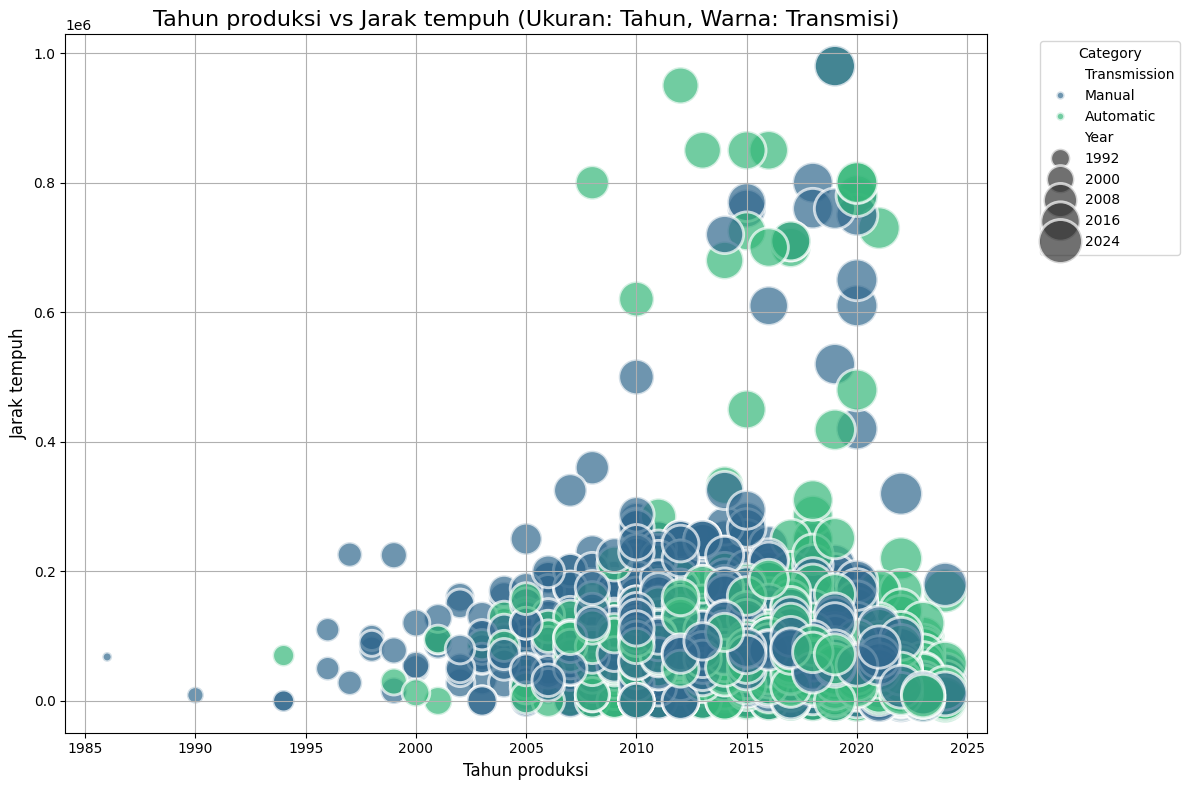

In [70]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Year', y='kmDriven', size='Year', hue='Transmission', data=df, sizes=(50, 1000), alpha=0.7, palette='viridis')
plt.title('Tahun produksi vs Jarak tempuh (Ukuran: Tahun, Warna: Transmisi)', fontsize=16)
plt.xlabel('Tahun produksi', fontsize=12)
plt.ylabel('Jarak tempuh', fontsize=12)
plt.grid(True)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Dominasi Mobil Tahun Muda**: Kepadatan gelembung paling tinggi berada di sisi kanan grafik, menunjukkan stok unit didominasi oleh mobil keluaran 10 tahun terakhir.

**Segmentasi Transmisi**: Manual tersebar luas di semua tahun produksi, namun sangat padat pada jarak tempuh rendah hingga menengah. Automatic mulai muncul signifikan sejak tahun 2010 dan mendominasi beberapa unit dengan jarak tempuh sangat tinggi.



---
Berdasarkan hasil diatas, penjual mobil bekas harus dapat action kedepannya dengan cara:
* Karena grafik menunjukkan banyak unit Automatic memiliki jarak tempuh ekstrem, penjual harus memberikan jaminan tambahan pada bagian transmisi untuk meyakinkan pembeli. Jual dengan harga murah untuk unit ini karena angka kilometer yang tinggi biasanya menjadi penghalang psikologis bagi pembeli mobil automatic.
* Unit produksi tahun 1985-2000 yang berada di posisi bawah grafik adalah aset berharga. Pasarkan unit ini untuk para kolektor barang antik untuk mendapatkan keuntungan di atas harga pasar rata-rata.
* Melihat gelembung di tahun 2024 memiliki ukuran beragam namun jarak tempuh sangat rendah, pastikan penjualan unit ini cepat sebelum terjadi penurunan harga yang tajam saat memasuki tahun berikutnya.


## **Heatmap**

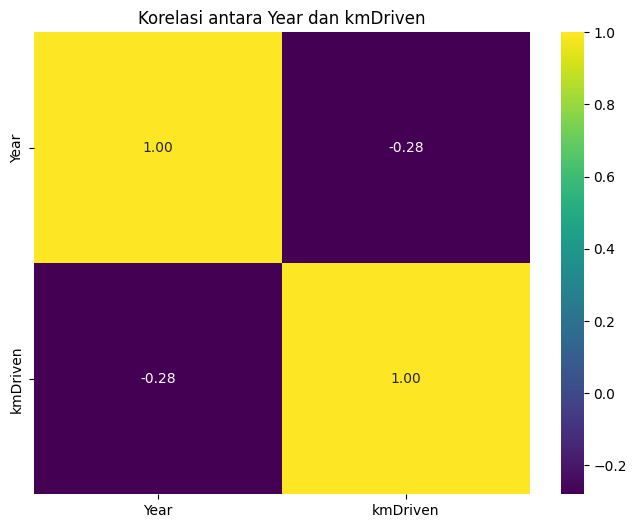

In [68]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['Year', 'kmDriven']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi antara Year dan kmDriven')
plt.show()

**Year --> Year** = 1.00
Artinya korelasi sempurna dengan dirinya sendiri.

**kmDriven --> kmDriven** = 1.00
variabel selalu berkorelasi sempurna dengan dirinya sendiri.

**Year --> kmDriven** = -0.28
Ini adalah nilai yang penting. Nilai -0.28 menunjukkan korelasi negatif yang lemah.

Artinya:

Semakin baru tahun mobil, biasanya kilometer yang ditempuh cenderung lebih sedikit. Sebaliknya, mobil yang lebih tua cenderung memiliki kmDriven lebih tinggi. Namun karena nilainya hanya -0.28 (lemah), hubungan ini tidak terlalu kuat. Artinya masih banyak mobil baru yang kilometernya tinggi atau mobil lama yang kilometernya rendah.

---
Berdasarkan hasil diatas, penjual mobil bekas harus dapat action kedepannya dengan cara:

* Fokus pada Kombinasi Tahun Baru + km Rendah Mobil dengan kombinasi ini biasanya paling mudah dijual dan harga lebih tinggi.

# **Menyimpan Dataset**

In [45]:
df.to_csv('/content/drive/MyDrive/avd/[Bersih] used_car_dataset.csv', index=False)